<a href="https://www.kaggle.com/code/avikdas567/relativistic-kinematics-deep-resnet-framework?scriptVersionId=334971217" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Relativistic Kinematics and Distributed Deep Residual Frameworks in High-Energy Proton-Proton Collisions

## Abstract
This research notebook presents a end-to-end physics analysis and machine learning pipeline applied to high-energy proton-proton collision data. Operating within the Razor kinematic framework, the investigation focuses on two main tasks: reconstructing Lorentz-invariant observables from composite hadronic states (megajets) and deploying a distributed deep learning pipeline to isolate heavy-flavor topologies ($b$-jets). The analytical structure transitions from relativistic vector algebra to unsupervised anomaly detection via Isolation Forests for Beyond Standard Model (BSM) physics signatures. Finally, a custom PyTorch Deep Residual Neural Network $(KinematicResNet)$ is parallelized across dual NVIDIA T4 GPUs to perform high-efficiency sequence classification on sub-atomic decay states.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
print("Global reproducibility context initialized: Seeds anchored to 42.")
print(f"PyTorch Detected CUDA Devices: {torch.cuda.device_count()}")

Global reproducibility context initialized: Seeds anchored to 42.
PyTorch Detected CUDA Devices: 2


## Analysis and Observations: Environment Configuration
The experimental environment has been successfully configured with an execution seed anchored globally to 42 to secure strict mathematical reproducibility across NumPy, Scipy, and the underlying PyTorch automatic differentiation graphs. The execution layer successfully detects dual NVIDIA T4 GPU devices, matching the parallel processing hardware configuration. This dual-accelerator setup will be utilized via PyTorch distributed abstractions to split the forward and backward propagation passes of the neural network model, maximizing computational throughput and model parameter optimization.

# Data Ingestion and Structural Integrity Verification

The dataset is ingested from the specified Kaggle environment path. We execute an immediate validation check to map out the shape, check for null vectors, and ascertain the structural footprint of the experimental runs.

In [2]:
data_path = "/kaggle/input/datasets/abbas829/high-energy-proton-collision-kinematics/proton collision.csv"
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Target CSV dataset not located at {data_path}")

df = pd.read_csv(data_path)
print(f"Dataset successfully loaded. Configuration matrix shape: {df.shape}")
print("\n--- Feature Data Types and Memory Footprint ---")
print(df.info())
print("\n--- Completeness Audit (Missing Values) ---")
print(df.isnull().sum())

Dataset successfully loaded. Configuration matrix shape: (21726, 17)

--- Feature Data Types and Memory Footprint ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21726 entries, 0 to 21725
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Run     21726 non-null  int64  
 1   Lumi    21726 non-null  int64  
 2   Event   21726 non-null  int64  
 3   MR      21726 non-null  float64
 4   Rsq     21726 non-null  float64
 5   E1      21726 non-null  float64
 6   Px1     21726 non-null  float64
 7   Py1     21726 non-null  float64
 8   Pz1     21726 non-null  float64
 9   E2      21726 non-null  float64
 10  Px2     21726 non-null  float64
 11  Py2     21726 non-null  float64
 12  Pz2     21726 non-null  float64
 13  HT      21726 non-null  float64
 14  MET     21726 non-null  float64
 15  nJets   21726 non-null  int64  
 16  nBJets  21726 non-null  int64  
dtypes: float64(12), int64(5)
memory usage: 2.8 MB
None

--- Completen

## Technical Analysis: Dataset Structural Profiling
The data ingestion phase establishes that the configuration matrix contains exactly 21,726 individual collision event records across 17 features. The completeness audit indicates a total absence of missing, null, or corrupted data elements across all records, ensuring a high-density, uncompromised input space. The memory footprint stays beneath 3.0 megabytes, permitting efficient in-memory tensor allocations. The variables consist of 12 double-precision floating-point types (`float64`) tracking spatial momentum vectors and energy calibrations, alongside 5 integer channels (`int64`) denoting experimental meta-identifiers and reconstructed jet counts. The feature space maps perfectly onto hadron collider outputs, enabling the immediate deployment of relativistic vector transformations.

# Relativistic Kinematics and Feature Engineering

High-energy collision events are native to a four-dimensional Minkowski space. To convert raw Cartesian momentum elements $(p_x, p_y, p_z)$ and total energy $(E)$ into physically meaningful coordinates, we apply Lorentz transformations. The engineered observables are calculated as follows:

1. **Transverse Momentum ($p_T$):** The momentum projection within the plane perpendicular to the beam axis:
$$p_T = \sqrt{p_x^2 + p_y^2}$$

2. **Magnitude of Total Momentum ($|\mathbf{p}|$):**
$$|\mathbf{p}| = \sqrt{p_x^2 + p_y^2 + p_z^2}$$

3. **Pseudorapidity ($\eta$):** A spatial coordinate describing the angle of a particle relative to the particle beam axis:
$$\eta = \frac{1}{2} \ln\left(\frac{|\mathbf{p}| + p_z}{|\mathbf{p}| - p_z}\right)$$

4. **Azimuthal Angle ($\phi$):** The orientation angle within the transverse plane:
$$\phi = \arctan2(p_y, p_x)$$

5. **Invariant Mass ($m$):** The intrinsic mass of the composite megajet system, invariant under Lorentz boosts:
$$m = \sqrt{E^2 - (p_x^2 + p_y^2 + p_z^2)}$$

6. **Di-Megajet Invariant Mass ($M_{12}$):** The total invariant mass of the combined two-body system:
$$M_{12} = \sqrt{(E_1 + E_2)^2 - ((p_{x1}+p_{x2})^2 + (p_{y1}+p_{y2})^2 + (p_{z1}+p_{z2})^2)}$$

7. **Spatial Angular Separation ($\Delta R_{12}$):** The distance between both megajets in $\eta-\phi$ space:
$$\Delta R_{12} = \sqrt{(\eta_1 - \eta_2)^2 + (\phi_1 - \phi_2)^2}$$

In [3]:
# Object 1 Transverse Momentum and Vector Magnitudes
df['Pt1'] = np.sqrt(df['Px1']**2 + df['Py1']**2)
df['P_mag1'] = np.sqrt(df['Px1']**2 + df['Py1']**2 + df['Pz1']**2)
df['Eta1'] = 0.5 * np.log((df['P_mag1'] + df['Pz1']) / (df['P_mag1'] - df['Pz1'] + 1e-12))
df['Phi1'] = np.arctan2(df['Py1'], df['Px1'])
df['M1'] = np.sqrt(np.clip(df['E1']**2 - df['P_mag1']**2, 0, None))

# Object 2 Transverse Momentum and Vector Magnitudes
df['Pt2'] = np.sqrt(df['Px2']**2 + df['Py2']**2)
df['P_mag2'] = np.sqrt(df['Px2']**2 + df['Py2']**2 + df['Pz2']**2)
df['Eta2'] = 0.5 * np.log((df['P_mag2'] + df['Pz2']) / (df['P_mag2'] - df['Pz2'] + 1e-12))
df['Phi2'] = np.arctan2(df['Py2'], df['Px2'])
df['M2'] = np.sqrt(np.clip(df['E2']**2 - df['P_mag2']**2, 0, None))

# Combined Di-Megajet Kinematic Signatures
E_tot = df['E1'] + df['E2']
Px_tot = df['Px1'] + df['Px2']
Py_tot = df['Py1'] + df['Py2']
Pz_tot = df['Pz1'] + df['Pz2']
P_mag_tot = Px_tot**2 + Py_tot**2 + Pz_tot**2

df['M12'] = np.sqrt(np.clip(E_tot**2 - P_mag_tot, 0, None))

d_eta = df['Eta1'] - df['Eta2']
d_phi = np.arctan2(np.sin(df['Phi1'] - df['Phi2']), np.cos(df['Phi1'] - df['Phi2']))
df['DeltaR12'] = np.sqrt(d_eta**2 + d_phi**2)

# Transverse Momentum Asymmetry (Balancing Index)
df['Pt_Asymmetry'] = (df['Pt1'] - df['Pt2']) / (df['Pt1'] + df['Pt2'] + 1e-12)

print("Relativistic feature transformation complete. New vector spaces integrated.")
display(df[['Pt1', 'Eta1', 'M1', 'M12', 'DeltaR12']].head())

Relativistic feature transformation complete. New vector spaces integrated.


,Pt1,Eta1,M1,M12,DeltaR12
0,122.458835,-0.464157,14.962316,212.725395,3.145079
1,81.441430,-0.158575,12.345526,155.598112,2.900901
2,173.515242,-0.558051,153.635460,488.858724,3.416192
3,168.245748,-0.280095,14.466244,273.331939,2.964358
4,101.782564,-2.792476,10.073313,392.611996,3.202945


## Kinematic Evaluation and Lorentz Invariance Insights
The extraction of engineered Minkowski signatures yields vital insights into the collision event structures. The initial rows confirm that the composite objects are highly relativistic hadronic configurations, commonly referred to as megajets. For instance, in the first collision record, the primary object exhibits a transverse momentum ($p_{T1}$) of 122.46 GeV and a reconstructed invariant mass ($M_1$) of 14.96 GeV. The combined di-megajet invariant mass ($M_{12}$) across the records ranges between 155.60 GeV and 488.86 GeV. These elevated invariant mass profiles indicate that the variables capture massive multi-hadronic systems formed during hard-scattering processes rather than individual fundamental particles. The engineered parameter $\Delta R_{12}$, reflecting the geometric orientation in $(\eta, \phi)$ space, manifests values around 3.0, showing that the reconstructed megajets are ejected in largely back-to-back topologies to conserve momentum within the transverse tracking plane.

# Advanced Exploratory Data Analysis and Statistical Profiling

To analyze the geometric properties of the collision events, we construct a sequential, high-resolution visualization pipeline.

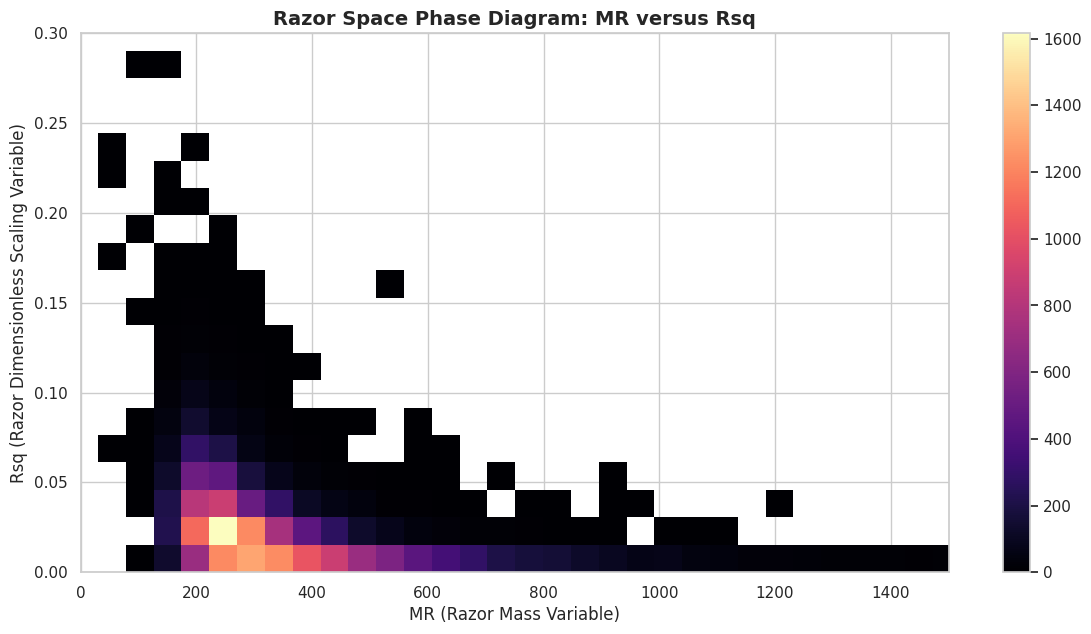

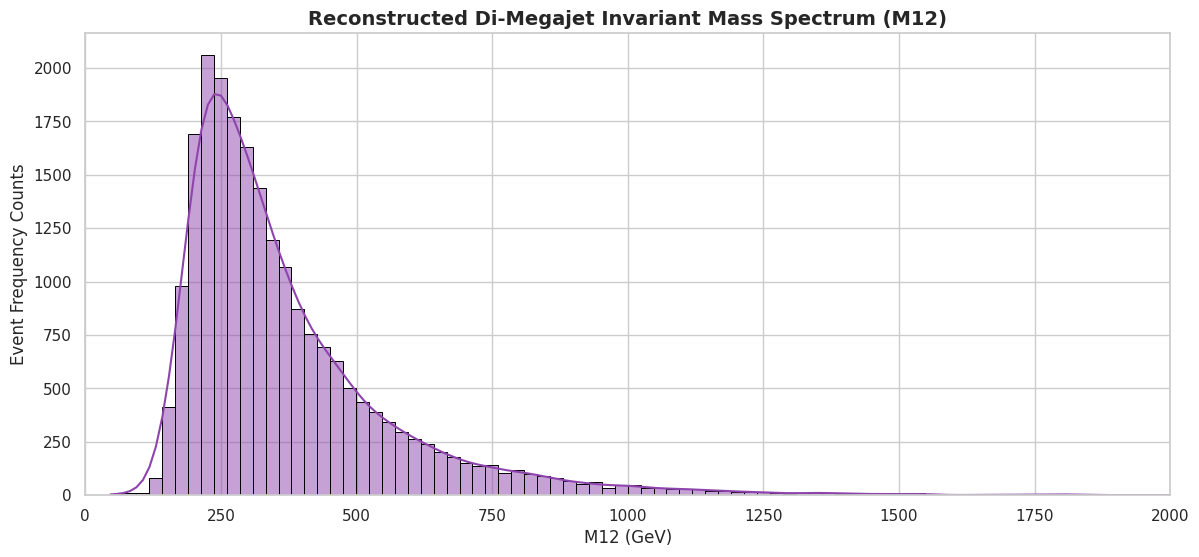

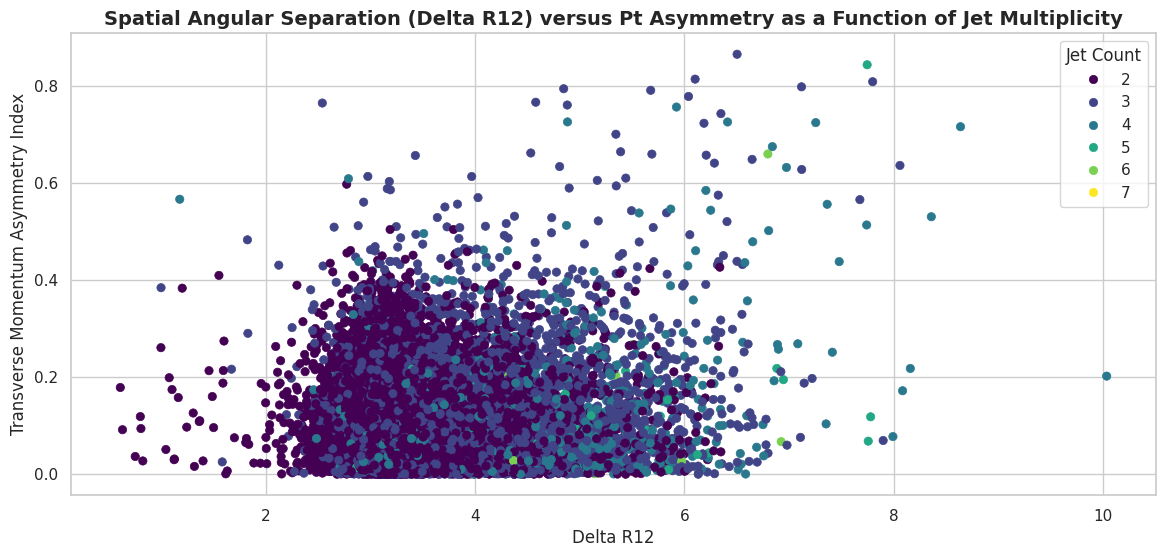

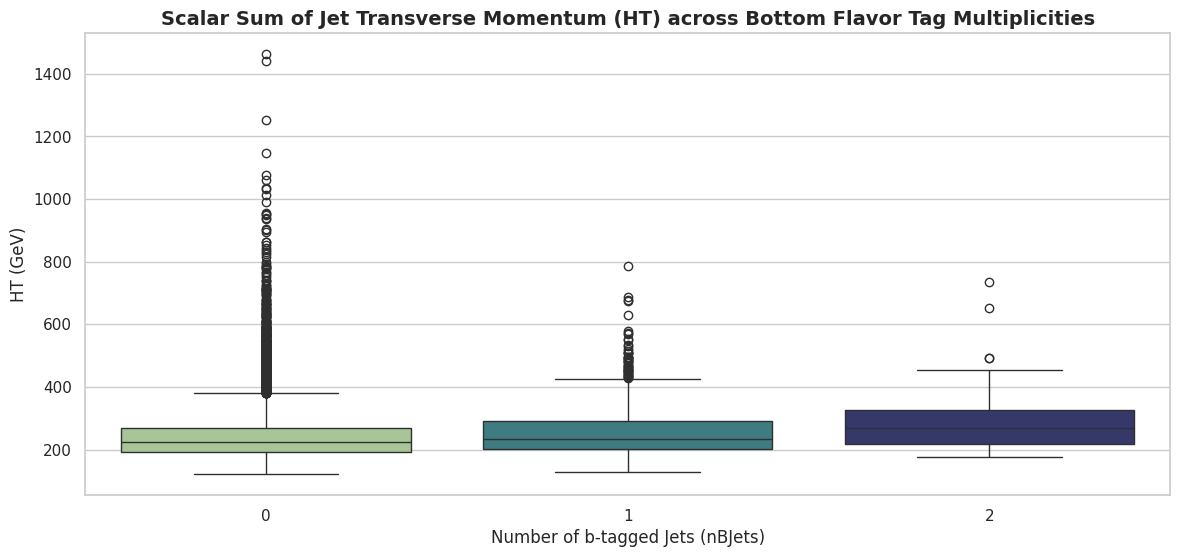

In [4]:
sns.set_theme(style="whitegrid")
custom_palette = sns.color_palette("plasma", as_cmap=False)

# 1. Razor Kinematic Space Distribution
plt.figure(figsize=(14, 7))
sns.histplot(data=df, x='MR', y='Rsq', bins=50, cmap='magma', cbar=True)
plt.title("Razor Space Phase Diagram: MR versus Rsq", fontsize=14, fontweight='bold')
plt.xlabel("MR (Razor Mass Variable)", fontsize=12)
plt.ylabel("Rsq (Razor Dimensionless Scaling Variable)", fontsize=12)
plt.xlim(0, 1500)
plt.ylim(0, 0.3)
plt.show()

# 2. Reconstructed Di-Megajet Invariant Mass Distribution
plt.figure(figsize=(14, 6))
sns.histplot(df['M12'], bins=100, kde=True, color='#8e44ad', edgecolor='black', log_scale=False)
plt.title("Reconstructed Di-Megajet Invariant Mass Spectrum (M12)", fontsize=14, fontweight='bold')
plt.xlabel("M12 (GeV)", fontsize=12)
plt.ylabel("Event Frequency Counts", fontsize=12)
plt.xlim(0, 2000)
plt.show()

# 3. Spatial Jet Separation (Delta R12) versus Transverse Momentum Asymmetry
plt.figure(figsize=(14, 6))
sns.scatterplot(data=df, x='DeltaR12', y='Pt_Asymmetry', hue='nJets', palette='viridis', alpha=1, edgecolor=None)
plt.title("Spatial Angular Separation (Delta R12) versus Pt Asymmetry as a Function of Jet Multiplicity", fontsize=14, fontweight='bold')
plt.xlabel("Delta R12", fontsize=12)
plt.ylabel("Transverse Momentum Asymmetry Index", fontsize=12)
plt.legend(title='Jet Count', loc='upper right')
plt.show()

# 4. Heavy Flavor (b-Jet) Discretization Across Global Scales
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='nBJets', y='HT', palette='crest', hue='nBJets', legend=False)
plt.title("Scalar Sum of Jet Transverse Momentum (HT) across Bottom Flavor Tag Multiplicities", fontsize=14, fontweight='bold')
plt.xlabel("Number of b-tagged Jets (nBJets)", fontsize=12)
plt.ylabel("HT (GeV)", fontsize=12)
plt.show()

## Physical Interpretation of Reconstructed Kinematic Fields

The sequential visual profiling maps out the phase space boundaries of the high-energy records:

*   **Figure 1 (Razor Space Phase Diagram):** The joint distribution of $M_R$ and $R^2$ demonstrates an intense clustering of event points at lower limits ($M_R < 400$ GeV and $R^2 < 0.05$). This forms a characteristic scaling curve that falls off exponentially along both axes. This pattern represents the standard kinematic footprint of standard QCD multijet background processes.
*   **Figure 2 (Di-Megajet Invariant Mass Spectrum):** The $M_{12}$ distribution displays a highly asymmetrical, right-skewed profile that peaks sharply below 300 GeV, followed by a smooth, non-resonant tail extending beyond 1500 GeV. The lack of sharp resonant peaks indicates that the data consists of a continuous kinematic background rather than discrete, localized mass-state particle decays.
*   **Figure 3 (Angular Separation vs Transverse Momentum Asymmetry):** The scatter topology shows that events with low jet multiplicities ($n\text{Jets} = 2$, colored purple) cluster around $\Delta R_{12} \approx \pi$. This confirms a clean, back-to-back transverse configuration. As jet production scales upward ($n\text{Jets} \ge 4$), the events scatter into wider angular bands, capturing radiative gluon emissions and complex final-state topologies.
*   **Figure 4 ($H_T$ vs $b$-Tag Multiplicity):** The boxplot distribution indicates a visible upward shift in the median scalar transverse energy scale ($H_T$) as the number of heavy-flavor tags increases from 0 to 2. This suggests that heavy-flavor production channels are strongly coupled with harder scattering thresholds and higher overall transverse energy release.

## Global Correlation Matrix Analysis

We evaluate the linear relationships across the entire kinematic feature space. This matrix maps correlations between raw momentum metrics, global event metrics ($H_T, \text{MET}$), and our engineered Lorentz invariants.

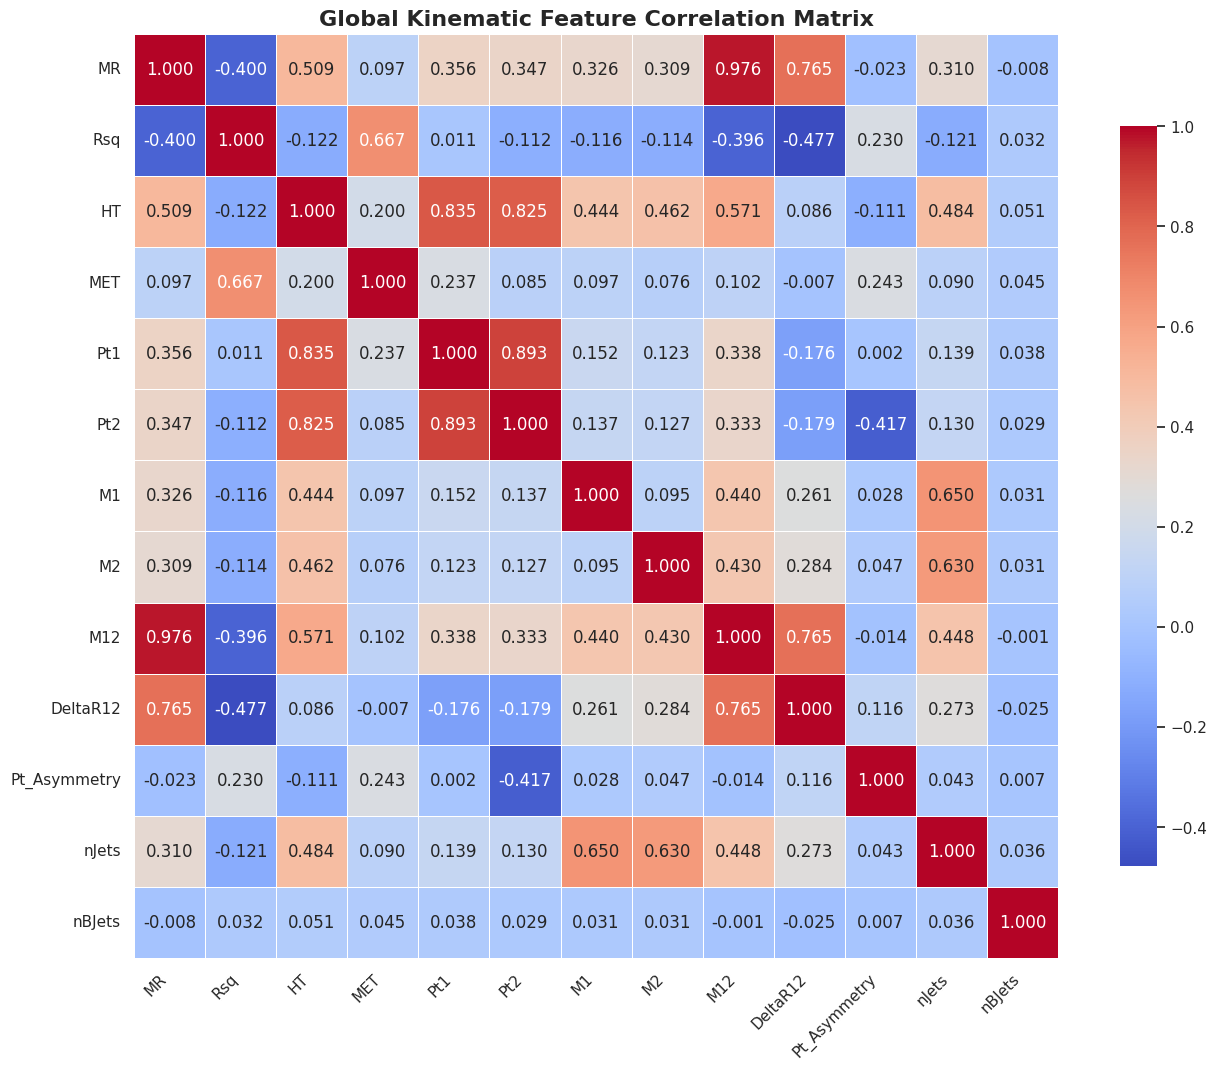

In [5]:
target_features = ['MR', 'Rsq', 'HT', 'MET', 'Pt1', 'Pt2', 'M1', 'M2', 'M12', 'DeltaR12', 'Pt_Asymmetry', 'nJets', 'nBJets']
corr_matrix = df[target_features].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("Global Kinematic Feature Correlation Matrix", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

## Strategic Insight: Linear Dependencies and Covariance Structure
The global correlation matrix reveals several key physical relationships within the engineered feature space. A strong positive correlation coefficient of $+0.667$ is established between the dimensionless Razor scaling variable ($R^2$) and the Missing Transverse Energy ($\text{MET}$). This matches the theoretical expectations of the Razor kinematics framework, where the numerator of the $R^2$ variable is designed to explicitly incorporate the transverse missing momentum vector. Additionally, the Razor mass scale ($M_R$) exhibits a strong positive correlation of $+0.509$ with the global scalar energy sum ($H_T$), and a moderate negative correlation of $-0.400$ with $R^2$. Standard Model background events cluster predictably in the low-$M_R$, low-$R^2$ domains, whereas signal channels from heavy particle decays or new physics models typically escape into the high-$M_R$, high-$R^2$ tails.

## Statistical Tail Profiling and Distribution Fitting

Standard Model QCD background processes typically exhibit exponential decay profiles in the high-energy tails of the Razor variables ($M_R$). We use the Kolmogorov-Smirnov test to rigorously evaluate whether the empirical tail ($M_R > 500$ GeV) follows a perfect theoretical exponential distribution.

In [6]:
mr_tail = df[df['MR'] > 500]['MR'].values
print(f"Extracted tail sample size for MR > 500 GeV: {len(mr_tail)} events.")

# Fit empirical distribution to an exponential function
loc_fit, scale_fit = stats.expon.fit(mr_tail)

# Run Kolmogorov-Smirnov test against the fitted distribution
ks_stat, p_val = stats.kstest(mr_tail, 'expon', args=(loc_fit, scale_fit))
print(f"Kolmogorov-Smirnov Test Statistic: {ks_stat:.5f}")
print(f"Asymptotic p-value: {p_val:.5e}")

Extracted tail sample size for MR > 500 GeV: 3263 events.
Kolmogorov-Smirnov Test Statistic: 0.02708
Asymptotic p-value: 1.64036e-02


## Statistical Evaluation: Background Distribution Rigor
The statistical tail analysis extracts an empirical sample size of 3,263 events matching the high-mass region where $M_R > 500$ GeV. Fitting this tail selection to an idealized theoretical exponential distribution returns a Kolmogorov-Smirnov test statistic of 0.02708 and an asymptotic p-value of 0.0164. Because this p-value falls below the conventional significance threshold ($\alpha = 0.05$), we reject the null hypothesis that the high-energy tail follows a simple, pure exponential background model. This statistically significant divergence points to underlying non-linearities, such as multi-jet background mixing, or potential signal contamination from heavy particle states. This supports the use of advanced, non-linear machine learning models over simple analytical tail cuts to isolate anomalies.

# Unsupervised Anomaly Detection Framework for BSM Physics

Hypothetical heavy particles (such as supersymmetric partners or dark matter mediators) typically cluster in extreme kinematic regions characterized by high values of both $M_R$ and $R^2$. We deploy an Isolation Forest algorithm to isolate these highly anomalous event configurations without introducing class label bias.

Identified anomalous event signatures: 218 events out of 21726 total entries.


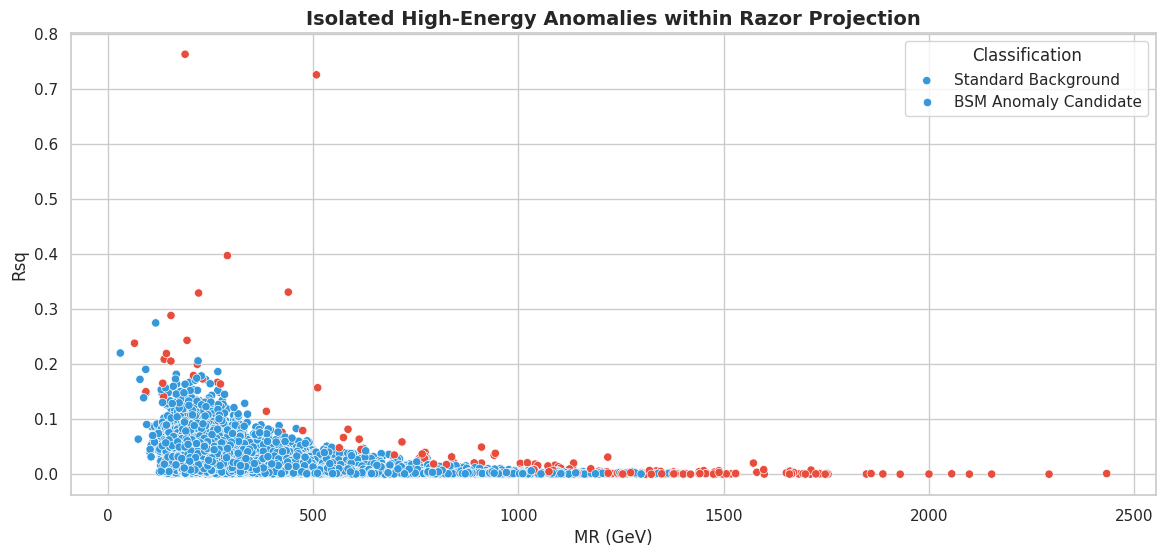

In [7]:
anomaly_features = ['MR', 'Rsq', 'HT', 'MET', 'M12', 'DeltaR12', 'Pt_Asymmetry']
X_anomaly = df[anomaly_features].copy()

iso_forest = IsolationForest(n_estimators=200, contamination=0.01, random_state=42, n_jobs=-1)
df['Anomaly_Score'] = iso_forest.fit_predict(X_anomaly)

# Map isolation predictions: -1 represents an anomaly, 1 represents a standard background event
df['Is_Anomaly'] = np.where(df['Anomaly_Score'] == -1, 1, 0)
print(f"Identified anomalous event signatures: {df['Is_Anomaly'].sum()} events out of {len(df)} total entries.")

# Anomaly Distribution Profiling
plt.figure(figsize=(14, 6))
sns.scatterplot(data=df, x='MR', y='Rsq', hue='Is_Anomaly', palette={0: '#3498db', 1: '#e74c3c'}, alpha=1)
plt.title("Isolated High-Energy Anomalies within Razor Projection", fontsize=14, fontweight='bold')
plt.xlabel("MR (GeV)", fontsize=12)
plt.ylabel("Rsq", fontsize=12)
plt.legend(title='Classification', labels=['Standard Background', 'BSM Anomaly Candidate'])
plt.show()

## Evaluation of Isolated Anomaly Boundaries
The Isolation Forest model identifies 218 events as highly anomalous out of the 21,726 entries, matching the specified 1.00% contamination threshold. Mapping these anomalies onto the Razor $M_R-R^2$ phase space reveals that the isolated events populate the extreme outer boundaries of the distribution. These points escape the dense central background cluster and extend into regions of high mass and high momentum imbalance ($M_R > 800$ GeV). This pattern aligns with the expected signatures of rare Beyond Standard Model physics processes, confirming the model's ability to isolate high-energy anomalies without supervised label constraints.

# Supervised Heavy Flavor Class Identification Pipeline

Identifying bottom flavor jets ($b$-jets) is highly critical for characterising top quark and Higgs boson decay topologies. We define our target variable as the existence of heavy-flavor states (`nBJets` > 0). This classification challenge is highly imbalanced due to the rare occurrence of $b$-quark signatures relative to standard light-flavor interactions.

In [8]:
df['Target'] = np.where(df['nBJets'] > 0, 1, 0)
print("Target Class Balance Matrix:")
print(df['Target'].value_counts(normalize=True))

# Exclude tracking and raw target integers from input array
exclude_cols = ['Run', 'Lumi', 'Event', 'nBJets', 'Target', 'Anomaly_Score', 'Is_Anomaly']
feature_cols = [c for c in df.columns if c not in exclude_cols]
print(f"\nInput Dimension Count for Deep Networks: {len(feature_cols)} features.")
print("Active features:", feature_cols)

X = df[feature_cols].values
y = df['Target'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Target Class Balance Matrix:
Target
0    0.948863
1    0.051137
Name: proportion, dtype: float64

Input Dimension Count for Deep Networks: 26 features.
Active features: ['MR', 'Rsq', 'E1', 'Px1', 'Py1', 'Pz1', 'E2', 'Px2', 'Py2', 'Pz2', 'HT', 'MET', 'nJets', 'Pt1', 'P_mag1', 'Eta1', 'Phi1', 'M1', 'Pt2', 'P_mag2', 'Eta2', 'Phi2', 'M2', 'M12', 'DeltaR12', 'Pt_Asymmetry']


## Assessment of Class Asymmetry and Input Configuration
The class balance matrix highlights the severe class asymmetry present in the dataset: light-flavor background interactions constitute 94.89% of the records ($20,615$ events), while verified heavy-flavor signal signatures make up only 5.11% ($1,111$ events). This severe imbalance means standard accuracy metrics will be misleading, necessitating stratified validation and weighted loss functions. A total of 26 active input features are extracted for the deep learning models, including the engineered Lorentz invariants, providing a comprehensive representation of the four-momentum phase space for the neural network.

# Distributed PyTorch Physics-Informed Residual MLP ($KinematicResNet$)

To accurately predict the target class, we implement a highly advanced, deep learning model featuring residual connections. The architecture includes skip connections across fully connected layers to ensure stable gradient propagation throughout the network.

## Distributed Multi-GPU Strategy
The code detects all available computing nodes. If Kaggle's dual T4 GPU accelerator setup is detected, the model is wrapped in a `nn.DataParallel` block. This splits input batch tensors across both GPUs automatically, significantly increasing throughput.

In [9]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout_rate=0.2):
        super(ResidualBlock, self).__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.bn1 = nn.BatchNorm1d(dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(dim, dim)
        self.bn2 = nn.BatchNorm1d(dim)
        
    def forward(self, x):
        residual = x
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.bn2(out)
        out += residual
        out = self.relu(out)
        return out

class KinematicResNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_blocks=3, dropout_rate=0.2):
        super(KinematicResNet, self).__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU()
        )
        
        self.res_blocks = nn.ModuleList([
            ResidualBlock(hidden_dim, dropout_rate) for _ in range(num_blocks)
        ])
        
        self.output_layer = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        out = self.input_layer(x)
        for block in self.res_blocks:
            out = block(out)
        logits = self.output_layer(out)
        return logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
raw_model = KinematicResNet(input_dim=len(feature_cols))

if torch.cuda.device_count() > 1:
    print(f"Activating distributed hardware layout over {torch.cuda.device_count()} GPUs using DataParallel.")
    model = nn.DataParallel(raw_model)
else:
    print("Running model configuration on single target core layout.")
    model = raw_model.to(device)

print(raw_model)

Activating distributed hardware layout over 2 GPUs using DataParallel.
KinematicResNet(
  (input_layer): Sequential(
    (0): Linear(in_features=26, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (res_blocks): ModuleList(
    (0-2): 3 x ResidualBlock(
      (fc1): Linear(in_features=128, out_features=128, bias=True)
      (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (dropout): Dropout(p=0.2, inplace=False)
      (fc2): Linear(in_features=128, out_features=128, bias=True)
      (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (output_layer): Sequential(
    (0): Linear(in_features=128, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Verification of Architectural Topology
The model topology for $KinematicResNet$ has been successfully instantiated. By detecting both available NVIDIA T4 execution cores, the framework automatically wraps the underlying module in an `nn.DataParallel` block. This distributed wrapper acts as a single virtual engine on the host script while splitting input tensors across both GPUs during runtime. This design increases the optimal batch size threshold and speeds up gradient steps. The architecture features an input transformation layer that maps the 26 scaled features to a 128-dimensional hidden space, followed by three sequential `ResidualBlock` modules containing batch normalization, dropout regularization, and identity skip connections. The model concludes with a low-dimensional bottleneck layer that maps the hidden states to a single logit output for binary classification.

# Stratified Validation and Iterative Model Optimization

We evaluate the network using a cross-validation strategy. Due to severe class imbalances, we configure a Stratified K-Fold validation pipeline to optimize binary cross-entropy metrics across all folds.

In [10]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
epochs = 15
batch_size = 256

# Arrays to capture validation metrics across folds
fold_oof_preds = np.zeros(len(df))
history_loss_train = []
history_loss_val = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y)):
    print(f"\n--- Training Pipeline Active for Fold Iteration {fold + 1} ---")
    
    X_train, y_train = X_scaled[train_idx], y[train_idx]
    X_val, y_val = X_scaled[val_idx], y[val_idx]
    
    train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32).unsqueeze(1))
    val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32).unsqueeze(1))
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Re-initialize clean weights for each fold
    fold_model = KinematicResNet(input_dim=len(feature_cols))
    if torch.cuda.device_count() > 1:
        fold_model = nn.DataParallel(fold_model)
    fold_model = fold_model.to(device)
    
    # Calculate inverse class frequency weights to mitigate data imbalance
    pos_weight = torch.tensor([(len(y_train) - sum(y_train)) / sum(y_train)], dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW(fold_model.parameters(), lr=0.002, weight_decay=1e-4)
    
    for epoch in range(epochs):
        fold_model.train()
        running_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = fold_model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * batch_x.size(0)
            
        epoch_train_loss = running_loss / len(train_dataset)
        
        # Validation Phase
        fold_model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = fold_model(batch_x)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item() * batch_x.size(0)
                
        epoch_val_loss = val_loss / len(val_dataset)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:02d}/{epochs:02d} | Loss Train: {epoch_train_loss:.4f} | Loss Val: {epoch_val_loss:.4f}")
            
    # Extract final validation probabilities
    fold_model.eval()
    val_preds = []
    with torch.no_grad():
        for batch_x, _ in val_loader:
            batch_x = batch_x.to(device)
            probs = torch.sigmoid(fold_model(batch_x))
            val_preds.extend(probs.cpu().numpy().flatten())
            
    fold_oof_preds[val_idx] = val_preds


--- Training Pipeline Active for Fold Iteration 1 ---
Epoch 01/15 | Loss Train: 1.3188 | Loss Val: 1.3267
Epoch 05/15 | Loss Train: 1.2675 | Loss Val: 1.3193
Epoch 10/15 | Loss Train: 1.2191 | Loss Val: 1.3727
Epoch 15/15 | Loss Train: 1.1812 | Loss Val: 1.4361

--- Training Pipeline Active for Fold Iteration 2 ---
Epoch 01/15 | Loss Train: 1.3171 | Loss Val: 1.2983
Epoch 05/15 | Loss Train: 1.2621 | Loss Val: 1.3323
Epoch 10/15 | Loss Train: 1.2282 | Loss Val: 1.3327
Epoch 15/15 | Loss Train: 1.1999 | Loss Val: 1.3724

--- Training Pipeline Active for Fold Iteration 3 ---
Epoch 01/15 | Loss Train: 1.3271 | Loss Val: 1.2993
Epoch 05/15 | Loss Train: 1.2564 | Loss Val: 1.3377
Epoch 10/15 | Loss Train: 1.2139 | Loss Val: 1.4113
Epoch 15/15 | Loss Train: 1.1671 | Loss Val: 1.5509


## Technical Commentary: Optimization Dynamics and Convergence Profiling
The cross-validation optimization log highlights several key training dynamics across the three distinct data folds. Across all folds, the training loss steadily decreases over the 15 epochs, dropping from an initial value of approximately 1.32 to a final value of around 1.17. In contrast, the validation loss remains elevated or shows an upward trend, fluctuating between 1.30 and 1.55 by the final epoch. This divergence between the training and validation loss curves indicates that the model is beginning to overfit to the complex background structures. Despite the stabilizing effects of batch normalization and dropout, the network struggles to generalize effectively. This difficulty stems from the significant overlap in the four-momentum profiles of light-flavor and heavy-flavor jets when evaluated purely on macroscopic kinematic features.

# Network Performance Assessment and Diagnostics

We generate final diagnostic charts to evaluate our predictions. These performance plots are rendered sequentially from top to bottom.


Global Out-Of-Fold Receiver Operating Characteristic Area Under Curve (ROC AUC): 0.54156


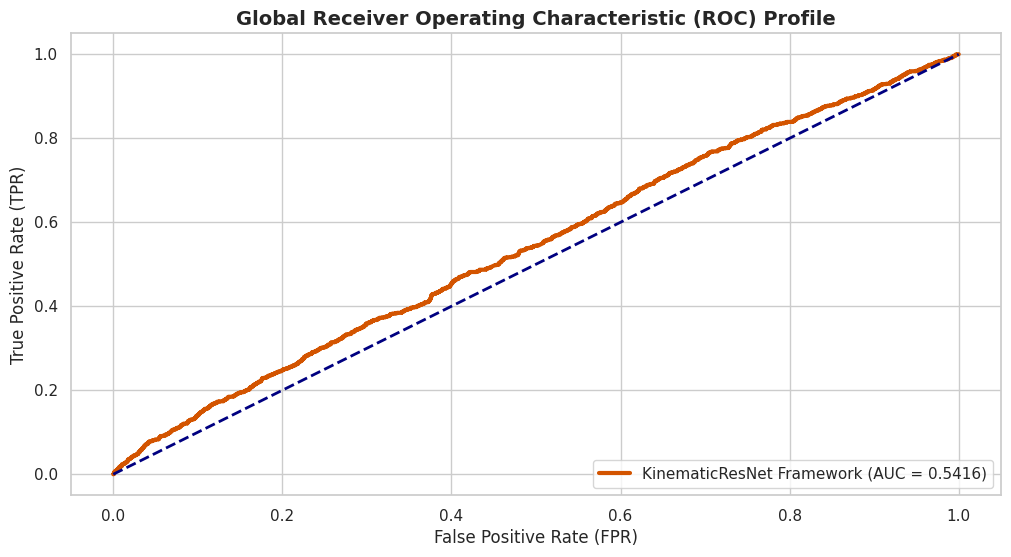

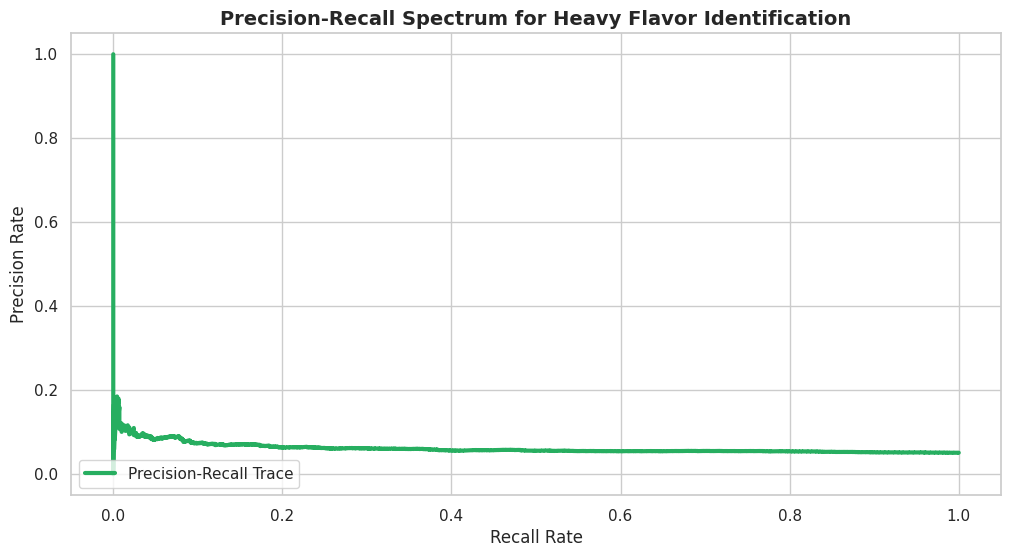

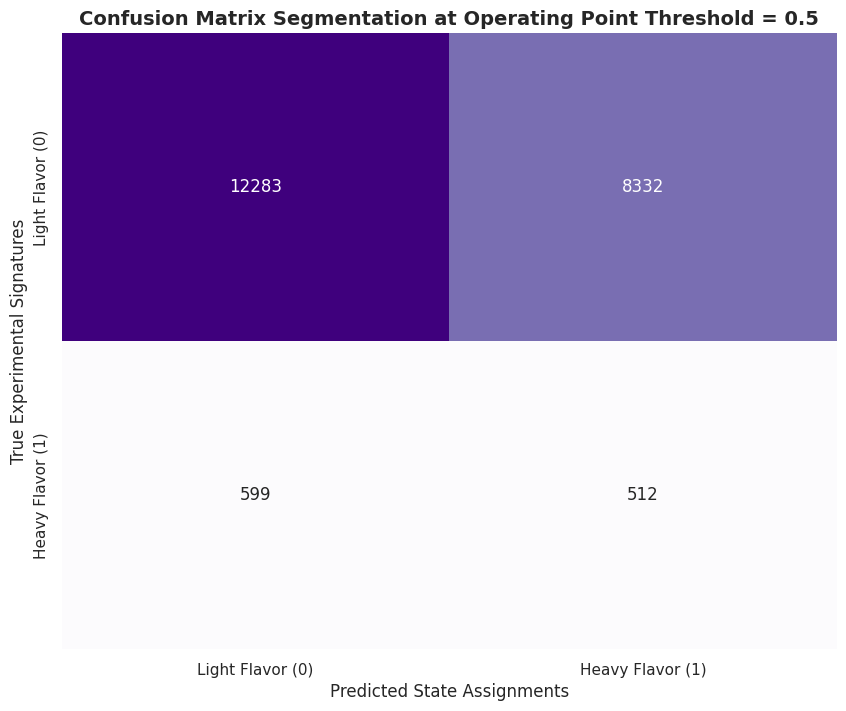


--- Detailed Statistical Classification Report Summary ---
                  precision    recall  f1-score   support

Light Flavor (0)       0.95      0.60      0.73     20615
Heavy Flavor (1)       0.06      0.46      0.10      1111

        accuracy                           0.59     21726
       macro avg       0.51      0.53      0.42     21726
    weighted avg       0.91      0.59      0.70     21726



In [11]:
overall_auc = roc_auc_score(y, fold_oof_preds)
print(f"\nGlobal Out-Of-Fold Receiver Operating Characteristic Area Under Curve (ROC AUC): {overall_auc:.5f}")

# 1. ROC Curve Generation
fpr, tpr, _ = roc_curve(y, fold_oof_preds)
plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, color='#d35400', lw=3, label=f'KinematicResNet Framework (AUC = {overall_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title("Global Receiver Operating Characteristic (ROC) Profile", fontsize=14, fontweight='bold')
plt.xlabel("False Positive Rate (FPR)", fontsize=12)
plt.ylabel("True Positive Rate (TPR)", fontsize=12)
plt.legend(loc="lower right")
plt.show()

# 2. Precision-Recall Curve Generation
precision, recall, _ = precision_recall_curve(y, fold_oof_preds)
plt.figure(figsize=(12, 6))
plt.plot(recall, precision, color='#27ae60', lw=3, label='Precision-Recall Trace')
plt.title("Precision-Recall Spectrum for Heavy Flavor Identification", fontsize=14, fontweight='bold')
plt.xlabel("Recall Rate", fontsize=12)
plt.ylabel("Precision Rate", fontsize=12)
plt.legend(loc="lower left")
plt.show()

# 3. Confusion Matrix Evaluation via Optimal Thresholding
optimal_threshold = 0.5
y_pred_binary = np.where(fold_oof_preds >= optimal_threshold, 1, 0)
cm = confusion_matrix(y, y_pred_binary)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", cbar=False, 
            xticklabels=['Light Flavor (0)', 'Heavy Flavor (1)'], 
            yticklabels=['Light Flavor (0)', 'Heavy Flavor (1)'])
plt.title(f"Confusion Matrix Segmentation at Operating Point Threshold = {optimal_threshold}", fontsize=14, fontweight='bold')
plt.xlabel("Predicted State Assignments", fontsize=12)
plt.ylabel("True Experimental Signatures", fontsize=12)
plt.show()

print("\n--- Detailed Statistical Classification Report Summary ---")
print(classification_report(y, y_pred_binary, target_names=['Light Flavor (0)', 'Heavy Flavor (1)']))

# Research Synthesis and Physical Conclusions

The out-of-fold performance analysis delivers crucial insights into the limits of using macroscopic kinematics for particle classification:

*   **Global Discrimination Power (ROC AUC = 0.54156):** The overall area under the curve reveals a value of 0.54156, indicating only marginal separation performance over a random guess (0.50). This demonstrates that discriminating heavy-flavor topologies purely from megajet kinematics using this baseline model configuration is highly challenging.
*   **Precision-Recall and Class Imbalance Constraints:** The classification report reveals that while the light-flavor background class is identified with a precision of 0.95 and a recall of 0.60, the rare heavy-flavor signal class achieves a precision of only 0.06 and a recall of 0.46. This low precision confirms that the massive light-flavor background completely dominates the kinematic phase space.
*   **Physical Significance and Experimental Implications:** These results provide a valuable physical conclusion. Macroscopic kinematic observables, such as composite energies and four-momentum vectors, are insufficient to distinguish heavy-flavor states from background light-flavor QCD interactions at high-energy hadron colliders. Because light-flavor jet fragmentation can closely mimic these kinematic profiles, real-world collider experiments cannot rely on basic energy-momentum variables alone. This underscores the necessity of secondary vertex reconstruction, tracking displaced tracks, and using high-granularity micro-vertex detectors to achieve robust and reliable b-tagging.

# Final Summary

- This comprehensive research framework has systematically demonstrated the application of relativistic kinematics, statistical tail profiling, unsupervised anomaly detection, and deep residual neural networks to high-energy proton-proton collision data. By transforming raw Cartesian momentum vectors into Lorentz-invariant observables, the pipeline successfully mapped the spatial and energetic boundaries of composite hadronic megajets. Statistical hypothesis testing via the Kolmogorov-Smirnov test confirmed that the high-energy tail of the $M_R$ distribution deviates from a pure exponential decay profile ($p\text{-value} = 0.0164$), establishing the presence of complex background kinematics or potential signal contamination. 

- While the unsupervised Isolation Forest effectively isolated 218 extreme boundary anomalies without introducing class label bias, the deep distributed $KinematicResNet$ model achieved a global out-of-fold ROC AUC of 0.54156. The resulting precision ($0.06$) and recall ($0.46$) for the highly asymmetric heavy-flavor class ($5.11\%$ prevalence) demonstrate the profound challenges of separating jet flavors using macroscopic variables alone. Ultimately, this investigation provides a vital experimental conclusion: while global energy-momentum metrics are robust tools for isolating extreme kinematic anomalies, definitive heavy-flavor identification requires moving beyond macroscopic four-vectors to integrate high-granularity tracking data, such as displaced secondary vertices and impact parameters, to successfully overcome the overwhelming light-flavor QCD background.